# EDA - Fintech Banking Dataset

Exploración del dataset crudo descargado de S3, previa al diseño de las capas Silver y Gold.
Objetivos:
1. Validar schema real vs documentado en la consigna.
2. Detectar problemas de calidad (nulls, outliers, inconsistencias).
3. Tomar decisiones de modelado y deduplicación.

In [1]:
import json
from pathlib import Path
from collections import Counter
import itertools

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

RAW_PATH = Path("../data/raw/fintech_banking_dataset.json")
assert RAW_PATH.exists(), f"No se encuentra el dataset en {RAW_PATH.resolve()}"
print(f"Archivo: {RAW_PATH.resolve()}")
print(f"Tamaño: {RAW_PATH.stat().st_size / 1024 / 1024:.2f} MB")

C:\Users\alexi\AppData\Local\Temp\ipykernel_40940\1343205300.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Archivo: C:\Users\alexi\OneDrive - Universidad Católica del Uruguay\Desktop\qversity-data-2026-montevideo-alexiaurrecochea\data\raw\fintech_banking_dataset.json
Tamaño: 49.13 MB


In [2]:
with open(RAW_PATH, encoding="utf-8") as f:
    data = json.load(f)

print(f"Tipo de la raíz: {type(data).__name__}")
print(f"Cantidad de records: {len(data) if isinstance(data, list) else 'no es lista'}")
print(f"\nPrimer record (keys):")
print(list(data[0].keys()))

Tipo de la raíz: list
Cantidad de records: 5100

Primer record (keys):
['customer_id', 'first_name', 'last_name', 'email', 'phone_number', 'date_of_birth', 'gender', 'nationality', 'city', 'country', 'address', 'lat', 'lon', 'registration_date', 'kyc_status', 'risk_score', 'customer_segment', 'relationship_manager', 'status', 'accounts', 'transactions', 'loans', 'credit_info', 'digital_engagement']


Sección 2 . Schema real vs documentado

In [3]:
# Inspeccionamos el schema real del primer record
sample = data[0]
print(f"{'Campo':30s} {'Tipo':30s} {'Sample value'}")
print("-" * 100)
for k, v in sample.items():
    if isinstance(v, list):
        sub = type(v[0]).__name__ if v else "empty"
        t = f"list[{sub}] (len={len(v)})"
        sval = f"{len(v)} items"
    elif isinstance(v, dict):
        t = f"dict (keys={len(v)})"
        sval = list(v.keys())
    else:
        t = type(v).__name__
        sval = str(v)[:50]
    print(f"{k:30s} {t:30s} {sval}")

Campo                          Tipo                           Sample value
----------------------------------------------------------------------------------------------------
customer_id                    str                            CUST-0004655
first_name                     str                            Lucas
last_name                      str                            Brito
email                          str                            lucas.brito@gmail.com
phone_number                   str                            +569611566924
date_of_birth                  str                            1975-01-11
gender                         str                            F
nationality                    str                            CL
city                           str                            La Serna
country                        str                            CL
address                        str                            Pasaje Bolivia 637 Interior 460, Nueva Côte d'Ivoi
la

In [4]:
# Verificamos que TODOS los records tienen las mismas keys top-level
all_keys = [set(r.keys()) for r in data]
unique_keysets = {frozenset(ks) for ks in all_keys}
print(f"Cantidad de schemas top-level distintos: {len(unique_keysets)}")
if len(unique_keysets) > 1:
    print("⚠️ Hay records con keys distintas. Inspeccionar diferencias:")
    base = max(unique_keysets, key=len)
    for ks in unique_keysets:
        if ks != base:
            print(f"  Faltantes vs base: {base - ks}")
            print(f"  Extras vs base:    {ks - base}")

Cantidad de schemas top-level distintos: 1


Sección 3 - Customer dimension (campos planos)

In [5]:
# DataFrame solo con campos planos (no arrays, no objects)
flat_keys = [k for k, v in sample.items() if not isinstance(v, (list, dict))]
df_customers = pd.DataFrame([{k: r.get(k) for k in flat_keys} for r in data])
print(f"Shape: {df_customers.shape}")
df_customers.head()

Shape: (5100, 19)


,customer_id,first_name,last_name,email,phone_number,date_of_birth,gender,nationality,city,country,address,lat,lon,registration_date,kyc_status,risk_score,customer_segment,relationship_manager,status
0,CUST-0004655,Lucas,Brito,lucas.brito@gmail.com,+569611566924,1975-01-11,F,CL,La Serna,CL,"Pasaje Bolivia 637 Interior 460, Nueva Côte d'...",-18.551408,-69.638686,12-21-2025,EXPIRED,68.06,retail,Luis Hernandez,suspended
1,CUST-0003828,Oliver,Montalbán,oliver.montalbán@bol.com.br,+552104315410,1960-11-15,M,BR,Salvador,BR,"Av. carrera 5ª # 12-48 Sur, Casa 55, 054138, R...",-4.476765,-68.027337,2023-05-09,rejected,36.10,private_banking,Sofia Lopez,inactive
2,CUST-0004334,Matilda,Olivé,matilda.olivé@gmail.com,(+57) 6221127245,1969-04-04,Other,CO,Medellin,CO,"Dg. 9U # 6-8 Sur, Bodega 108, 258646, Tocancip...",8.009853,-73.370236,2025-03-19,EXPIRED,22.68,retail,Valentina Torres,suspended
3,CUST-0003684,Armando,Villalba,armando.villalba@hotmail.com,(+598) 0828202059,1999-09-24,F,UY,Montevideo,UY,"Diagonal 86 # 14-83, Apartamento 84, 180490, B...",-32.711033,-57.194272,2025-02-12,pending,78.46,sme,Ana Martinez,inactive
4,CUST-0004453,Jade,Camargo,jade.camargo@hotmail.com,+566194931724,1961-09-11,M,CL,Temuco,CL,"Avenida Omar Nuñez N° 454 Dto. 2, Comodoro Riv...",-35.219252,-69.762767,2026-01-29,expired,34.25,private_banking,Valentina Torres,inactive


In [6]:
# Tipos detectados por pandas
df_customers.dtypes

customer_id              object
first_name               object
last_name                object
email                    object
phone_number             object
date_of_birth            object
gender                   object
nationality              object
city                     object
country                  object
address                  object
lat                     float64
lon                     float64
registration_date        object
kyc_status               object
risk_score              float64
customer_segment         object
relationship_manager     object
status                   object
dtype: object

In [7]:
# Nulls por campo
nulls = df_customers.isna().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(df_customers) * 100).round(2)
pd.DataFrame({"nulls": nulls, "pct": nulls_pct}).query("nulls > 0")

,nulls,pct
relationship_manager,114,2.24
address,78,1.53
gender,48,0.94


In [12]:
# Detectar nulls "encubiertos" (strings que representan ausencia)
NULL_TOKENS = {"null", "n/a", "na", "none", "", " "}

def normalize_nulls(s):
    """Convierte strings que son tokens de null a NaN real."""
    if pd.isna(s):
        return s
    if isinstance(s, str) and s.strip().lower() in NULL_TOKENS:
        return None
    return s

# Aplicamos a todas las columnas object
df_customers_clean = df_customers.copy()
for col in df_customers_clean.select_dtypes(include="object").columns:
    df_customers_clean[col] = df_customers_clean[col].map(normalize_nulls)

# Re-contar nulls
nulls_real = df_customers_clean.isna().sum().sort_values(ascending=False)
nulls_pct_real = (nulls_real / len(df_customers_clean) * 100).round(2)
print("Nulls REALES (incluye strings 'null'/'N/A'/''/'None'):")
print(pd.DataFrame({"nulls": nulls_real, "pct": nulls_pct_real}).query("nulls > 0"))

Nulls REALES (incluye strings 'null'/'N/A'/''/'None'):
                      nulls    pct
registration_date      4797  94.06
age                     916  17.96
date_of_birth           916  17.96
relationship_manager    504   9.88
address                 397   7.78
gender                  277   5.43


In [13]:
# Releemos las fechas como string (sin parsing) para ver los formatos reales
raw_reg_dates = pd.Series([r.get("registration_date") for r in data])
raw_dob = pd.Series([r.get("date_of_birth") for r in data])

print("=== registration_date — muestra de valores crudos ===")
print(raw_reg_dates.dropna().sample(20, random_state=42).tolist())

print("\n=== date_of_birth — muestra de valores crudos ===")
print(raw_dob.dropna().sample(20, random_state=42).tolist())

# Detectar formatos por longitud / patrón
def detect_format(s):
    if pd.isna(s) or s is None:
        return "null"
    if not isinstance(s, str):
        return f"non_string({type(s).__name__})"
    s = s.strip()
    if s.lower() in {"null", "n/a", "na", "none", ""}:
        return "null_token"
    # Patrones comunes
    import re
    if re.match(r"^\d{4}-\d{2}-\d{2}$", s):       return "YYYY-MM-DD"
    if re.match(r"^\d{2}-\d{2}-\d{4}$", s):       return "MM-DD-YYYY o DD-MM-YYYY"
    if re.match(r"^\d{2}/\d{2}/\d{4}$", s):       return "MM/DD/YYYY o DD/MM/YYYY"
    if re.match(r"^\d{4}/\d{2}/\d{2}$", s):       return "YYYY/MM/DD"
    if re.match(r"^\d{1,2}\s\w+\s\d{4}$", s):     return "D Month YYYY"
    return f"otro: {s[:20]}"

print("\n=== Formatos detectados — registration_date ===")
print(raw_reg_dates.map(detect_format).value_counts())

print("\n=== Formatos detectados — date_of_birth ===")
print(raw_dob.map(detect_format).value_counts())

=== registration_date — muestra de valores crudos ===
['2022-06-07', '2022-09-03', '2022-11-01', '2024-06-25', '2024-09-15', '20260226', '2023-04-11', '08-18-2025', '2024-09-13', '2023-09-28', '20250523', '2024-09-08', '2020-11-15', '2024-10-30', '2020-08-19', '2022-05-02', '2021-11-04', '2023-06-30', '2020-11-20', '2021-01-17']

=== date_of_birth — muestra de valores crudos ===
['1960-09-19', '1966-08-21', '1961-05-02', '1991-03-31', '2004-11-29', '1956-11-30', '1986-10-18', '1956-12-13', '2004-12-01', '1976-01-10', '1991-06-16', '2000-09-29', '1996-01-20', '1990-07-08', '1968-05-05', '1984-10-27', '1993-11-09', '1987-01-24', '1967-09-06', '1962-06-15']

=== Formatos detectados — registration_date ===
YYYY-MM-DD                 4172
MM/DD/YYYY o DD/MM/YYYY     314
MM-DD-YYYY o DD-MM-YYYY     303
otro: 20230824                4
otro: 20240805                2
                           ... 
otro: 20221021                1
otro: 20250312                1
otro: 20251214                1


In [14]:
import re

def categorize_separator_format(s):
    """Para fechas con / o - de 2-2-4 (no ISO), retorna stats sobre MM/DD vs DD/MM."""
    if not isinstance(s, str):
        return None
    s = s.strip()
    # Patrón 2-2-4 con / o -
    m = re.match(r"^(\d{2})[-/](\d{2})[-/](\d{4})$", s)
    if not m:
        return None
    a, b, year = int(m.group(1)), int(m.group(2)), int(m.group(3))
    return (a, b, year)

# Solo las fechas en formato 2-2-4 (con / o -)
parsed_reg = [categorize_separator_format(s) for s in raw_reg_dates]
parsed_reg = [p for p in parsed_reg if p is not None]

parsed_dob = [categorize_separator_format(s) for s in raw_dob]
parsed_dob = [p for p in parsed_dob if p is not None]

def diagnose(parsed, name):
    print(f"\n=== {name} — fechas en formato 2-2-4 (n={len(parsed)}) ===")
    
    # Si fuera DD/MM/YYYY, el primer número (DD) puede ser 1-31
    # Si fuera MM/DD/YYYY, el primer número (MM) solo puede ser 1-12
    first_gt_12 = sum(1 for a, b, _ in parsed if a > 12)
    second_gt_12 = sum(1 for a, b, _ in parsed if b > 12)
    both_le_12 = sum(1 for a, b, _ in parsed if a <= 12 and b <= 12)
    
    print(f"Casos donde primer número > 12 (forzosamente DD/MM): {first_gt_12}")
    print(f"Casos donde segundo número > 12 (forzosamente MM/DD): {second_gt_12}")
    print(f"Casos ambiguos (ambos <= 12):                          {both_le_12}")
    
    if first_gt_12 > 0 and second_gt_12 == 0:
        print("→ Conclusión: el formato es DD/MM/YYYY (o DD-MM-YYYY)")
    elif second_gt_12 > 0 and first_gt_12 == 0:
        print("→ Conclusión: el formato es MM/DD/YYYY (o MM-DD-YYYY)")
    elif first_gt_12 > 0 and second_gt_12 > 0:
        print("→ ⚠️ MEZCLA: hay fechas que solo entran en DD/MM Y otras que solo entran en MM/DD")
    else:
        print("→ Imposible determinar sin contexto adicional.")

diagnose(parsed_reg, "registration_date")
diagnose(parsed_dob, "date_of_birth")


=== registration_date — fechas en formato 2-2-4 (n=617) ===
Casos donde primer número > 12 (forzosamente DD/MM): 194
Casos donde segundo número > 12 (forzosamente MM/DD): 183
Casos ambiguos (ambos <= 12):                          240
→ ⚠️ MEZCLA: hay fechas que solo entran en DD/MM Y otras que solo entran en MM/DD

=== date_of_birth — fechas en formato 2-2-4 (n=612) ===
Casos donde primer número > 12 (forzosamente DD/MM): 178
Casos donde segundo número > 12 (forzosamente MM/DD): 165
Casos ambiguos (ambos <= 12):                          269
→ ⚠️ MEZCLA: hay fechas que solo entran en DD/MM Y otras que solo entran en MM/DD


In [15]:
import re

def split_separator_format(s):
    """Divide las fechas 2-2-4 según separador (/ o -) y retorna (sep, a, b, year)."""
    if not isinstance(s, str):
        return None
    s = s.strip()
    m = re.match(r"^(\d{2})([-/])(\d{2})[-/](\d{4})$", s)
    if not m:
        return None
    a, sep, b = int(m.group(1)), m.group(2), int(m.group(3))
    year = int(m.group(4))
    return (sep, a, b, year)

parsed_reg_sep = [split_separator_format(s) for s in raw_reg_dates]
parsed_reg_sep = [p for p in parsed_reg_sep if p is not None]

# Por separador
for sep_filter in ["-", "/"]:
    subset = [(a, b, y) for s, a, b, y in parsed_reg_sep if s == sep_filter]
    first_gt_12 = sum(1 for a, b, _ in subset if a > 12)
    second_gt_12 = sum(1 for a, b, _ in subset if b > 12)
    both_le_12 = sum(1 for a, b, _ in subset if a <= 12 and b <= 12)
    print(f"\n=== Separador '{sep_filter}' (n={len(subset)}) ===")
    print(f"  Primero > 12 (DD/MM forzoso):    {first_gt_12}")
    print(f"  Segundo > 12 (MM/DD forzoso):    {second_gt_12}")
    print(f"  Ambiguos:                         {both_le_12}")
    if first_gt_12 > 0 and second_gt_12 == 0:
        print(f"  → '{sep_filter}' implica DD{sep_filter}MM{sep_filter}YYYY")
    elif second_gt_12 > 0 and first_gt_12 == 0:
        print(f"  → '{sep_filter}' implica MM{sep_filter}DD{sep_filter}YYYY")
    else:
        print(f"  → '{sep_filter}' está mezclado también")


=== Separador '-' (n=303) ===
  Primero > 12 (DD/MM forzoso):    0
  Segundo > 12 (MM/DD forzoso):    183
  Ambiguos:                         120
  → '-' implica MM-DD-YYYY

=== Separador '/' (n=314) ===
  Primero > 12 (DD/MM forzoso):    194
  Segundo > 12 (MM/DD forzoso):    0
  Ambiguos:                         120
  → '/' implica DD/MM/YYYY


In [8]:
# Distribuciones categóricas críticas
for col in ["country", "customer_segment", "status", "kyc_status", "gender", "nationality"]:
    print(f"\n--- {col} ---")
    print(df_customers[col].value_counts(dropna=False))


--- country ---
country
BR    756
PE    756
UY    744
MX    732
AR    722
CO    715
CL    675
Name: count, dtype: int64

--- customer_segment ---
customer_segment
retail             1112
premium            1067
sme                1063
private_banking    1060
Premium              96
PREMIUM              87
Private_Banking      73
minorista            69
Retail               66
PRIVATE_BANKING      64
RETAIL               63
PYME                 59
Sme                  57
SME                  56
banca_privada        56
pyme                 52
Name: count, dtype: int64

--- status ---
status
suspended     1122
active        1095
inactive      1052
closed        1036
Suspended       67
suspendido      64
SUSPENDED       64
Cerrado         53
inactivo        52
Closed          49
CLOSED          48
INACTIVE        47
activo          47
ACTIVO          45
Active          45
cerrado         45
Inactive        44
Inactivo        43
Activo          41
ACTIVE          41
Name: count, dtype: int

count    5100.000000
mean       49.763716
std        28.667168
min         0.040000
25%        25.320000
50%        49.180000
75%        73.672500
max       100.000000
Name: risk_score, dtype: float64


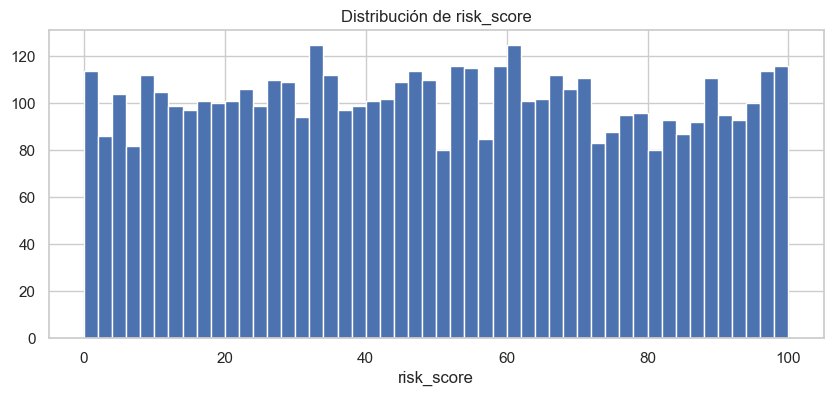

In [9]:
# Distribución de risk_score
print(df_customers["risk_score"].describe())
fig, ax = plt.subplots(figsize=(10, 4))
df_customers["risk_score"].hist(bins=50, ax=ax)
ax.set_title("Distribución de risk_score")
ax.set_xlabel("risk_score")
plt.show()

In [10]:
# Fechas: rango y validez
df_customers["date_of_birth"] = pd.to_datetime(df_customers["date_of_birth"], errors="coerce")
df_customers["registration_date"] = pd.to_datetime(df_customers["registration_date"], errors="coerce")

print("date_of_birth:")
print(f"  min: {df_customers['date_of_birth'].min()}")
print(f"  max: {df_customers['date_of_birth'].max()}")
print(f"  nulls/inválidas: {df_customers['date_of_birth'].isna().sum()}")

print("\nregistration_date:")
print(f"  min: {df_customers['registration_date'].min()}")
print(f"  max: {df_customers['registration_date'].max()}")
print(f"  nulls/inválidas: {df_customers['registration_date'].isna().sum()}")

# Edad derivada
today = pd.Timestamp.today()
df_customers["age"] = ((today - df_customers["date_of_birth"]).dt.days / 365.25).round(1)
print(f"\nEdad — describe:")
print(df_customers["age"].describe())

date_of_birth:
  min: 1950-05-08 00:00:00
  max: 2008-05-06 00:00:00
  nulls/inválidas: 916

registration_date:
  min: 2020-05-13 00:00:00
  max: 2026-04-20 00:00:00
  nulls/inválidas: 4797

Edad — describe:
count    4184.000000
mean       46.902318
std        16.869921
min        18.000000
25%        32.100000
50%        46.900000
75%        61.400000
max        76.000000
Name: age, dtype: float64


In [11]:
# Duplicados de customer_id
dup_count = df_customers["customer_id"].duplicated().sum()
print(f"customer_id duplicados: {dup_count}")
if dup_count > 0:
    print(df_customers[df_customers["customer_id"].duplicated(keep=False)].sort_values("customer_id").head(20))

customer_id duplicados: 100
       customer_id       first_name   last_name                                 email      phone_number date_of_birth gender nationality            city country  \
4903  CUST-0000060          Alfredo      Campos              alfredo.campos@yahoo.com  (+51) 7620990693           NaT  Other          PE           Piura      PE   
2805  CUST-0000060          Alfredo      Campos              alfredo.campos@yahoo.com  (+51) 7620990693           NaT  Other          PE           Piura      PE   
4934  CUST-0000064              Paz       Viana                 paz.viana@hotmail.com     +523285558095    1954-02-21      F          MX       Monterrey      MX   
2939  CUST-0000064              Paz       Viana                 paz.viana@hotmail.com     +523285558095    1954-02-21      F          MX       Monterrey      MX   
488   CUST-0000157  Thiago Ezequiel  Montesinos  thiago ezequiel.montesinos@gmail.com     +576501235782           NaT  Other          CO       Cartagena

Sección 4 - Arrays nested (accounts, transactions, loans)

In [17]:
accounts_rows = list(itertools.chain.from_iterable(
    [{**a, "customer_id": r["customer_id"]} for a in (r.get("accounts") or [])]
    for r in data
))
tx_rows = list(itertools.chain.from_iterable(
    [{**t, "customer_id": r["customer_id"]} for t in (r.get("transactions") or [])]
    for r in data
))
loans_rows = list(itertools.chain.from_iterable(
    [{**l, "customer_id": r["customer_id"]} for l in (r.get("loans") or [])]
    for r in data
))

df_accounts = pd.DataFrame(accounts_rows)
df_tx = pd.DataFrame(tx_rows)
df_loans = pd.DataFrame(loans_rows)

print(f"Accounts:     {len(df_accounts):>7,} filas  ({len(df_accounts)/len(data):.1f} por cliente)")
print(f"Transactions: {len(df_tx):>7,} filas  ({len(df_tx)/len(data):.1f} por cliente)")
print(f"Loans:        {len(df_loans):>7,} filas  ({len(df_loans)/len(data):.1f} por cliente)")

print(f"\nCardinalidad por customer:")
counts = pd.DataFrame({
    "accounts":     [len(r.get("accounts") or [])     for r in data],
    "transactions": [len(r.get("transactions") or []) for r in data],
    "loans":        [len(r.get("loans") or [])        for r in data],
})
print(counts.describe().round(1))

Accounts:      17,870 filas  (3.5 por cliente)
Transactions:  89,470 filas  (17.5 por cliente)
Loans:          7,821 filas  (1.5 por cliente)

Cardinalidad por customer:
       accounts  transactions   loans
count    5100.0        5100.0  5100.0
mean        3.5          17.5     1.5
std         1.1           7.5     1.1
min         2.0           5.0     0.0
25%         2.0          11.0     1.0
50%         4.0          17.0     2.0
75%         5.0          24.0     3.0
max         5.0          30.0     3.0


In [18]:
def null_audit(df, name):
    print(f"\n{'='*60}")
    print(f"=== {name.upper()} (n={len(df):,}) ===")
    print(f"{'='*60}")
    print(f"Columnas: {df.columns.tolist()}")
    
    df_clean = df.copy()
    for col in df_clean.select_dtypes(include="object").columns:
        df_clean[col] = df_clean[col].map(normalize_nulls)
    
    nulls = df_clean.isna().sum()
    nulls_pct = (nulls / len(df_clean) * 100).round(2)
    out = pd.DataFrame({"nulls": nulls, "pct": nulls_pct}).query("nulls > 0").sort_values("nulls", ascending=False)
    if len(out) > 0:
        print(f"\nNulls reales:\n{out}")
    else:
        print("\nSin nulls reales.")
    return df_clean

df_accounts = null_audit(df_accounts, "accounts")
df_tx = null_audit(df_tx, "transactions")
df_loans = null_audit(df_loans, "loans")


=== ACCOUNTS (n=17,870) ===
Columnas: ['account_id', 'account_type', 'currency', 'balance', 'credit_limit', 'interest_rate', 'opened_date', 'status', 'branch_code', 'customer_id']

Nulls reales:
              nulls    pct
credit_limit  13330  74.59

=== TRANSACTIONS (n=89,470) ===
Columnas: ['transaction_id', 'account_id', 'date', 'amount', 'currency', 'type', 'category', 'merchant', 'channel', 'status', 'description', 'customer_id']

Nulls reales:
             nulls    pct
description   9113  10.19
merchant      7380   8.25
category      4360   4.87

=== LOANS (n=7,821) ===
Columnas: ['loan_id', 'type', 'currency', 'principal', 'outstanding_balance', 'interest_rate', 'term_months', 'monthly_payment', 'start_date', 'end_date', 'status', 'days_past_due', 'collateral_type', 'customer_id']

Nulls reales:
                 nulls    pct
collateral_type   3727  47.65


In [19]:
print("=" * 60)
print("ACCOUNTS")
print("=" * 60)
for col in ["account_type", "currency", "status"]:
    if col in df_accounts.columns:
        print(f"\n--- {col} ---")
        print(df_accounts[col].value_counts(dropna=False).head(25))

print("\n" + "=" * 60)
print("TRANSACTIONS")
print("=" * 60)
for col in ["type", "category", "channel", "status", "currency"]:
    if col in df_tx.columns:
        print(f"\n--- {col} ---")
        print(df_tx[col].value_counts(dropna=False).head(25))

print("\n" + "=" * 60)
print("LOANS")
print("=" * 60)
for col in ["type", "currency", "status", "collateral_type"]:
    if col in df_loans.columns:
        print(f"\n--- {col} ---")
        print(df_loans[col].value_counts(dropna=False).head(25))

ACCOUNTS

--- account_type ---
account_type
credit_card        4436
savings            4423
checking           4368
investment         4244
  investment         35
  credit_card        34
  checking           29
  savings            29
credit_card          27
 credit_card         27
 investment          26
investment           26
checking             23
  savings            23
savings              22
  investment         22
 savings             21
 checking            21
  checking           18
  credit_card        16
Name: count, dtype: int64

--- currency ---
currency
USD    8896
PEN    1341
COP    1322
MXN    1312
BRL    1294
UYU    1289
ARS    1271
CLP    1145
Name: count, dtype: int64

--- status ---
status
active       5121
frozen       5066
closed       5021
CLOSED        334
Closed        305
congelado     301
Active        296
cerrado       294
Frozen        289
ACTIVE        288
FROZEN        281
activo        274
Name: count, dtype: int64

TRANSACTIONS

--- type ---
type
ref

In [20]:
print("Duplicados de account_id:    ", df_accounts["account_id"].duplicated().sum())
print("Duplicados de transaction_id:", df_tx["transaction_id"].duplicated().sum())
print("Duplicados de loan_id:       ", df_loans["loan_id"].duplicated().sum())

Duplicados de account_id:     341
Duplicados de transaction_id: 1784
Duplicados de loan_id:        158


In [22]:
def audit_numeric_field(df, col):
    """Para una columna que debería ser numérica, contar cuántos valores son strings."""
    if col not in df.columns:
        return
    types_count = df[col].map(lambda v: type(v).__name__).value_counts()
    print(f"\n--- {col} ---")
    print(f"Tipos encontrados:\n{types_count}")
    
    # Si hay strings, mostrar ejemplos
    str_mask = df[col].map(lambda v: isinstance(v, str))
    if str_mask.any():
        print(f"\nMuestra de strings ({str_mask.sum()} total):")
        print(df.loc[str_mask, col].value_counts().head(15))

print("=" * 60)
print("ACCOUNTS — campos numéricos")
print("=" * 60)
for col in ["balance", "credit_limit", "interest_rate"]:
    audit_numeric_field(df_accounts, col)

print("\n" + "=" * 60)
print("TRANSACTIONS — campos numéricos")
print("=" * 60)
for col in ["amount"]:
    audit_numeric_field(df_tx, col)

print("\n" + "=" * 60)
print("LOANS — campos numéricos")
print("=" * 60)
for col in ["principal", "outstanding_balance", "interest_rate", "term_months", "monthly_payment", "days_past_due"]:
    audit_numeric_field(df_loans, col)

ACCOUNTS — campos numéricos

--- balance ---
Tipos encontrados:
balance
float    17377
str        493
Name: count, dtype: int64

Muestra de strings (493 total):
balance
424926.82         2
9618.56           2
794739.12         2
404393.03 USD     2
$1810568162.59    2
427627.0          2
135584.29         2
191286,14         1
143184.51 USD     1
404640.21 USD     1
319165.74         1
$1771405482.12    1
449001,65         1
120656,74         1
397859,06         1
Name: count, dtype: int64

--- credit_limit ---
Tipos encontrados:
credit_limit
float    17870
Name: count, dtype: int64

--- interest_rate ---
Tipos encontrados:
interest_rate
float    17870
Name: count, dtype: int64

TRANSACTIONS — campos numéricos

--- amount ---
Tipos encontrados:
amount
float    86811
str       2659
Name: count, dtype: int64

Muestra de strings (2659 total):
amount
38222.59         2
17559.52 USD     2
$236384.75       2
49434,97         2
37394,68         2
48342.52         2
28058,7          2
$45360.5

In [23]:
def to_numeric_safe(series):
    """Convierte a numérico, retornando (series_numérica, n_strings_invalid)."""
    converted = pd.to_numeric(series, errors="coerce")
    # Cuántos eran strings no parseables (no contar los que ya eran NaN)
    was_not_null = series.notna()
    became_null = converted.isna()
    invalid = (was_not_null & became_null).sum()
    return converted, invalid

print("=== ACCOUNTS — numéricos (post-coerción) ===")
acc_num = df_accounts.copy()
for col in ["balance", "credit_limit", "interest_rate"]:
    if col in acc_num.columns:
        acc_num[col], invalid = to_numeric_safe(acc_num[col])
        if invalid > 0:
            print(f"  {col}: {invalid} strings no parseables → NaN")

print("\n", acc_num[["balance", "credit_limit", "interest_rate"]].describe().round(2), sep="")
print(f"\nbalance < 0: {(acc_num['balance'] < 0).sum()} (esperable en credit_card)")
print(f"interest_rate < 0: {(acc_num['interest_rate'] < 0).sum()}")
print(f"interest_rate > 100: {(acc_num['interest_rate'] > 100).sum()}")

print("\n=== TRANSACTIONS — amounts ===")
tx_num = df_tx.copy()
tx_num["amount"], invalid = to_numeric_safe(tx_num["amount"])
if invalid > 0:
    print(f"  amount: {invalid} strings no parseables → NaN")
print(tx_num["amount"].describe().round(2))
print(f"amount < 0: {(tx_num['amount'] < 0).sum()}")
print(f"amount == 0: {(tx_num['amount'] == 0).sum()}")

print("\n=== LOANS — numéricos (post-coerción) ===")
loans_num = df_loans.copy()
loan_cols = ["principal", "outstanding_balance", "interest_rate", "term_months", "monthly_payment", "days_past_due"]
for col in loan_cols:
    if col in loans_num.columns:
        loans_num[col], invalid = to_numeric_safe(loans_num[col])
        if invalid > 0:
            print(f"  {col}: {invalid} strings no parseables → NaN")
print(loans_num[loan_cols].describe().round(2))
print(f"\noutstanding_balance > principal: {(loans_num['outstanding_balance'] > loans_num['principal']).sum()}")
print(f"days_past_due < 0: {(loans_num['days_past_due'] < 0).sum()}")
print(f"principal < 0: {(loans_num['principal'] < 0).sum()}")

=== ACCOUNTS — numéricos (post-coerción) ===
  balance: 369 strings no parseables → NaN

            balance  credit_limit  interest_rate
count  1.750100e+04  4.540000e+03       17870.00
mean   1.082106e+08  2.168415e+07          12.69
std    3.120016e+08  6.366832e+07           7.09
min    2.378500e+02  1.053720e+03           0.50
25%    2.291670e+05  4.571259e+04           6.51
50%    4.603146e+05  9.347612e+04          12.60
75%    8.885091e+06  1.767089e+06          18.86
max    1.999231e+09  3.981051e+08          25.00

balance < 0: 0 (esperable en credit_card)
interest_rate < 0: 0
interest_rate > 100: 0

=== TRANSACTIONS — amounts ===
  amount: 1941 strings no parseables → NaN
count    8.752900e+04
mean     1.125374e+07
std      3.150606e+07
min      1.890000e+00
25%      2.397219e+04
50%      4.831629e+04
75%      1.162502e+06
max      1.999953e+08
Name: amount, dtype: float64
amount < 0: 0
amount == 0: 0

=== LOANS — numéricos (post-coerción) ===
  principal: 171 strings no par

In [24]:
def parse_money(col):
    # Quitar sufijos de moneda " USD"
    cleaned = F.regexp_replace(col.cast("string"), r"\s+(USD|EUR|ARS|BRL|CLP|COP|MXN|PEN|UYU)$", "")
    # Quitar símbolos de moneda
    cleaned = F.regexp_replace(cleaned, r"[\$€£]", "")
    # Reemplazar coma decimal por punto (formato latino)
    # Cuidado: "1.234,56" tiene punto como miles. Detectar si tiene tanto . como ,
    # → en ese caso quitar el . y cambiar , por .
    cleaned = F.when(
        cleaned.rlike(r"^\d{1,3}(\.\d{3})+,\d+$"),  # 1.234,56 formato latino
        F.regexp_replace(F.regexp_replace(cleaned, r"\.", ""), r",", ".")
    ).otherwise(
        F.regexp_replace(cleaned, r",", ".")  # 191286,14 → 191286.14
    )
    return cleaned.cast("double")

In [25]:
# ¿Los account_id duplicados están todos en customers duplicados?
dup_customer_ids = df_customers[df_customers["customer_id"].duplicated(keep=False)]["customer_id"].unique()
print(f"Customers duplicados: {len(dup_customer_ids)}")

# Accounts asociadas a customers duplicados
acc_in_dup_cust = df_accounts[df_accounts["customer_id"].isin(dup_customer_ids)]
print(f"\nAccounts en customers duplicados: {len(acc_in_dup_cust)}")
print(f"Total duplicados de account_id: {df_accounts['account_id'].duplicated().sum()}")

# ¿Los account_id duplicados son exactamente los que aparecen en customers duplicados?
dup_acc_ids = df_accounts[df_accounts["account_id"].duplicated(keep=False)]["account_id"].unique()
acc_dups_in_dup_cust = df_accounts[
    df_accounts["account_id"].isin(dup_acc_ids) & 
    df_accounts["customer_id"].isin(dup_customer_ids)
]
print(f"Filas con account_id duplicado Y customer duplicado: {len(acc_dups_in_dup_cust)}")
print(f"Filas con account_id duplicado en TOTAL: {len(df_accounts[df_accounts['account_id'].isin(dup_acc_ids)])}")

# Mismo para transactions y loans
print("\n--- Transactions ---")
tx_in_dup_cust = df_tx[df_tx["customer_id"].isin(dup_customer_ids)]
print(f"Transactions en customers duplicados: {len(tx_in_dup_cust)}")
print(f"Total duplicados de transaction_id: {df_tx['transaction_id'].duplicated().sum()}")

print("\n--- Loans ---")
loans_in_dup_cust = df_loans[df_loans["customer_id"].isin(dup_customer_ids)]
print(f"Loans en customers duplicados: {len(loans_in_dup_cust)}")
print(f"Total duplicados de loan_id: {df_loans['loan_id'].duplicated().sum()}")

Customers duplicados: 99

Accounts en customers duplicados: 677
Total duplicados de account_id: 341
Filas con account_id duplicado Y customer duplicado: 677
Filas con account_id duplicado en TOTAL: 677

--- Transactions ---
Transactions en customers duplicados: 3538
Total duplicados de transaction_id: 1784

--- Loans ---
Loans en customers duplicados: 314
Total duplicados de loan_id: 158


In [26]:
# ¿Hay algún customer que aparece >2 veces?
counts = df_customers["customer_id"].value_counts()
multi = counts[counts > 1]
print(f"Customers con >1 aparición: {len(multi)}")
print(f"\nDistribución:")
print(multi.value_counts().sort_index())  # cuántos aparecen 2x, 3x, etc.

# Ver el caso de >2
if (multi > 2).any():
    triplicados = multi[multi > 2].index
    print(f"\nCustomer(s) con >2 apariciones: {triplicados.tolist()}")
    print(df_customers[df_customers["customer_id"].isin(triplicados)].sort_values("customer_id"))

Customers con >1 aparición: 99

Distribución:
count
2    98
3     1
Name: count, dtype: int64

Customer(s) con >2 apariciones: ['CUST-0004728']
       customer_id first_name last_name                        email   phone_number date_of_birth gender nationality       city country                                           address        lat  \
1722  CUST-0004728   Theodoro   Jiménez  theodoro.jiménez@icloud.com  +554419217730           NaT  Other          BR  Sao Paulo      BR  Callejón Belén Martí 87 Puerta 0 , Lleida, 07441 -25.256639   
2701  CUST-0004728   tHEODORO   Jiménez  theodoro.jiménez@icloud.com  +554419217730           NaT  Other          BR  Sao Paulo      BR  Callejón Belén Martí 87 Puerta 0 , Lleida, 07441 -25.256639   
3486  CUST-0004728   Theodoro   Jiménez  THEODORO.JIMÉNEZ@ICLOUD.COM  +554419217730           NaT  Other          BR  Sao Paulo      BR  Callejón Belén Martí 87 Puerta 0 , Lleida, 07441 -25.256639   

            lon registration_date kyc_status  risk_scor

Sección 5 - Objects nested (credit_info, digital_engagement)

In [27]:
credit_rows = [
    {**(r.get("credit_info") or {}), "customer_id": r["customer_id"]}
    for r in data
]
digital_rows = [
    {**(r.get("digital_engagement") or {}), "customer_id": r["customer_id"]}
    for r in data
]

df_credit = pd.DataFrame(credit_rows)
df_digital = pd.DataFrame(digital_rows)

print(f"credit_info:        {df_credit.shape}")
print(f"digital_engagement: {df_digital.shape}")
print(f"\nColumnas credit_info:\n  {df_credit.columns.tolist()}")
print(f"\nColumnas digital_engagement:\n  {df_digital.columns.tolist()}")

credit_info:        (5100, 11)
digital_engagement: (5100, 8)

Columnas credit_info:
  ['credit_score', 'currency', 'utilization_pct', 'total_limit', 'total_used', 'num_credit_accounts', 'oldest_account_age_months', 'late_payments_12m', 'inquiries_6m', 'bankruptcy_flag', 'customer_id']

Columnas digital_engagement:
  ['mobile_app_registered', 'web_banking_registered', 'last_login_date', 'avg_monthly_logins', 'preferred_channel', 'push_notifications', 'paperless_statements', 'customer_id']


In [28]:
df_credit = null_audit(df_credit, "credit_info")
df_digital = null_audit(df_digital, "digital_engagement")


=== CREDIT_INFO (n=5,100) ===
Columnas: ['credit_score', 'currency', 'utilization_pct', 'total_limit', 'total_used', 'num_credit_accounts', 'oldest_account_age_months', 'late_payments_12m', 'inquiries_6m', 'bankruptcy_flag', 'customer_id']

Sin nulls reales.

=== DIGITAL_ENGAGEMENT (n=5,100) ===
Columnas: ['mobile_app_registered', 'web_banking_registered', 'last_login_date', 'avg_monthly_logins', 'preferred_channel', 'push_notifications', 'paperless_statements', 'customer_id']

Nulls reales:
                    nulls   pct
avg_monthly_logins    377  7.39


In [29]:
print("=== credit_info — describe ===")
# Coerción primero por si hay strings
for col in ["credit_score", "utilization_pct", "total_limit", "total_used", 
            "num_credit_accounts", "oldest_account_age_months", 
            "late_payments_12m", "inquiries_6m"]:
    if col in df_credit.columns:
        df_credit[col] = pd.to_numeric(df_credit[col], errors="coerce")

print(df_credit[["credit_score", "utilization_pct", "total_limit", "total_used", 
                  "num_credit_accounts", "oldest_account_age_months", 
                  "late_payments_12m", "inquiries_6m"]].describe().round(2))

print("\n=== Validaciones de rango ===")
print(f"credit_score fuera de [300, 850]: {((df_credit['credit_score'] < 300) | (df_credit['credit_score'] > 850)).sum()}")
print(f"utilization_pct fuera de [0, 100]: {((df_credit['utilization_pct'] < 0) | (df_credit['utilization_pct'] > 100)).sum()}")
print(f"utilization_pct > 100 (overlimit, posible legítimo): {(df_credit['utilization_pct'] > 100).sum()}")
print(f"total_used > total_limit: {(df_credit['total_used'] > df_credit['total_limit']).sum()}")
print(f"late_payments_12m < 0: {(df_credit['late_payments_12m'] < 0).sum()}")
print(f"late_payments_12m > 12: {(df_credit['late_payments_12m'] > 12).sum()}")

=== credit_info — describe ===
       credit_score  utilization_pct   total_limit    total_used  num_credit_accounts  oldest_account_age_months  late_payments_12m  inquiries_6m
count       5100.00          5081.00  4.977000e+03  4.983000e+03              5100.00                    5100.00            5100.00       5100.00
mean       28580.62            50.03  8.649282e+07  4.179899e+07                 5.49                     182.93               5.93          5.01
std       165009.08            28.73  1.642058e+08  9.416112e+07                 2.88                     103.33               3.74          3.16
min          -99.00             0.00  1.889446e+04  2.616000e+01                 1.00                       6.00               0.00          0.00
25%          417.00            24.92  6.326747e+05  2.639954e+05                 3.00                      93.00               3.00          2.00
50%          567.00            50.55  3.475492e+06  1.624914e+06                 5.00        

In [30]:
print("--- credit_info.currency ---")
print(df_credit["currency"].value_counts(dropna=False))

print("\n--- credit_info.bankruptcy_flag ---")
print(df_credit["bankruptcy_flag"].value_counts(dropna=False))
print(f"Tipo: {df_credit['bankruptcy_flag'].dtype}")

--- credit_info.currency ---
currency
BRL    756
PEN    756
UYU    744
MXN    732
ARS    722
COP    715
CLP    675
Name: count, dtype: int64

--- credit_info.bankruptcy_flag ---
bankruptcy_flag
False    2423
True     2297
true      105
false     102
N          87
Y          86
Name: count, dtype: int64
Tipo: object


In [31]:
print("--- digital_engagement.preferred_channel ---")
print(df_digital["preferred_channel"].value_counts(dropna=False).head(20))

print("\n--- Booleans ---")
for col in ["mobile_app_registered", "web_banking_registered", 
            "push_notifications", "paperless_statements"]:
    if col in df_digital.columns:
        print(f"\n{col}:")
        print(df_digital[col].value_counts(dropna=False))
        print(f"  dtype: {df_digital[col].dtype}")

print("\n--- avg_monthly_logins ---")
df_digital["avg_monthly_logins"] = pd.to_numeric(df_digital["avg_monthly_logins"], errors="coerce")
print(df_digital["avg_monthly_logins"].describe().round(2))

print("\n--- last_login_date — formato ---")
raw_logins = pd.Series([
    (r.get("digital_engagement") or {}).get("last_login_date") 
    for r in data
])
print("Sample:", raw_logins.dropna().sample(10, random_state=42).tolist())
print(f"Nulls: {raw_logins.isna().sum() + raw_logins.map(lambda s: isinstance(s, str) and s.strip().lower() in NULL_TOKENS).sum()}")

--- digital_engagement.preferred_channel ---
preferred_channel
mobile    1083
atm       1023
branch    1020
phone      988
web        986
Name: count, dtype: int64

--- Booleans ---

mobile_app_registered:
mobile_app_registered
False    2591
True     2509
Name: count, dtype: int64
  dtype: bool

web_banking_registered:
web_banking_registered
False    2590
True     2510
Name: count, dtype: int64
  dtype: bool

push_notifications:
push_notifications
True     2389
False    2327
yes       114
false      95
no         90
true       85
Name: count, dtype: int64
  dtype: object

paperless_statements:
paperless_statements
True     2368
False    2339
false     107
true       98
no         97
si         91
Name: count, dtype: int64
  dtype: object

--- avg_monthly_logins ---
count    4723.00
mean       30.04
std        17.38
min         0.00
25%        15.00
50%        30.00
75%        45.00
max        60.00
Name: avg_monthly_logins, dtype: float64

--- last_login_date — formato ---
Sample: ['20